# **House Price Prediction Using Linear Regression**

## **Objective**
### Predict house prices using Linear Regression based on important housing features.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## **Dataset Loading**

In [38]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


## **Understanding Dataset**

In [39]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [40]:
df.shape

(1460, 81)

In [41]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 81 entries, Id to SalePrice
dtypes: float64(3), int64(35), object(43)
memory usage: 924.0+ KB


In [42]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## **Missing Value Analysis**

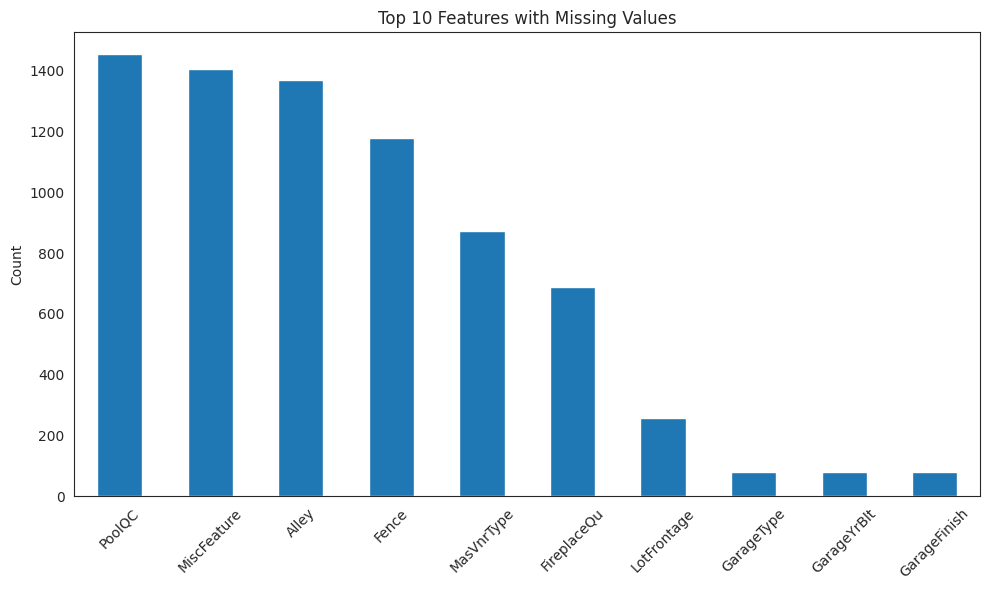

In [43]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
missing.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Features with Missing Values")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Correlation Heatmap**

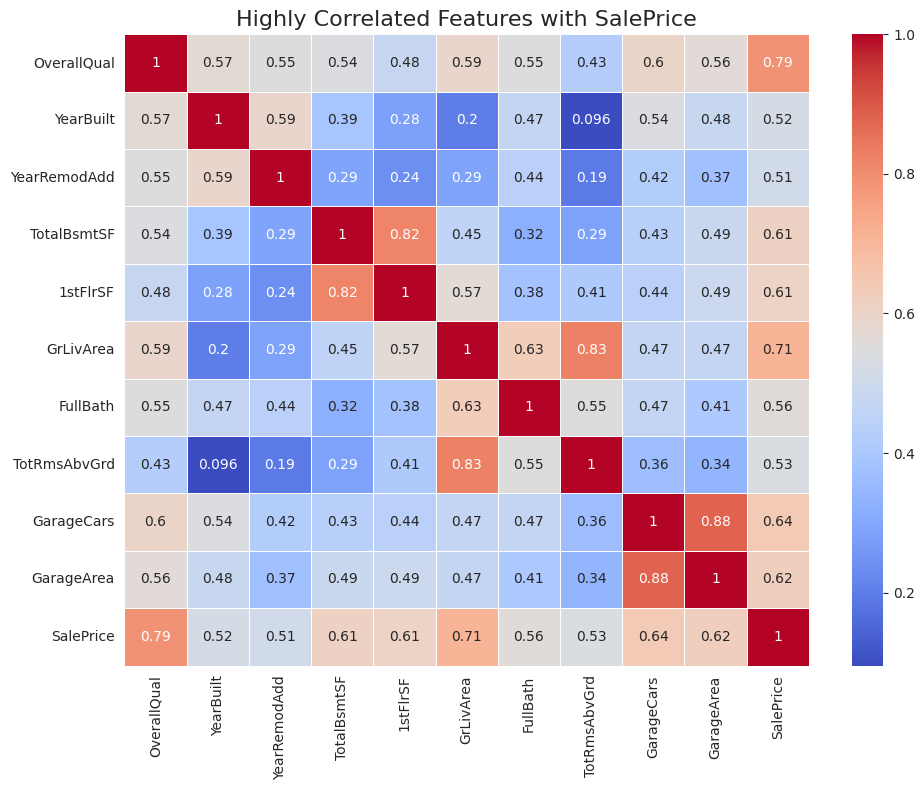

In [44]:
sns.set_style("white")

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

top_features = corr.index[abs(corr["SalePrice"]) > 0.5]

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Highly Correlated Features with SalePrice", fontsize=16)

plt.tight_layout()

plt.show()

## **Correlation Analysis of Features with House Prices**

In [45]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)[1:]

corr.head(15)

,SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


## **Observation**
Features like OverallQual, GrLivArea, GarageCars, and TotalBsmtSF have strong positive correlation with SalePrice.
These features are useful for building the prediction model.

## **SalePrice Distribution**

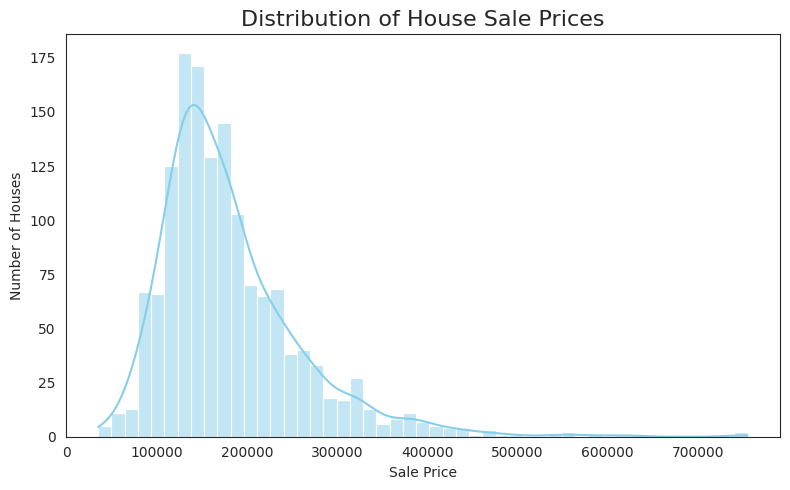

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True, color='skyblue')
plt.title("Distribution of House Sale Prices", fontsize=16)
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

## **Feature Relationship Analysis**

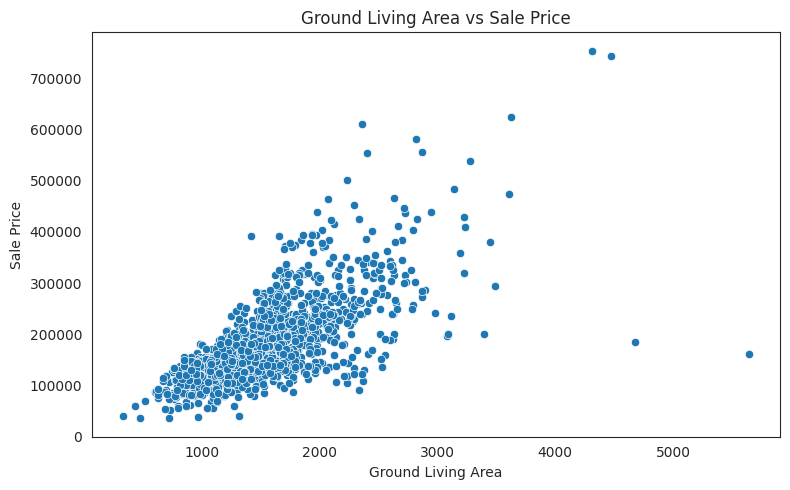

In [47]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['GrLivArea'],
    y=df['SalePrice']
)

plt.title("Ground Living Area vs Sale Price")
plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")
plt.tight_layout()
plt.show()

## **Outlier Detection**

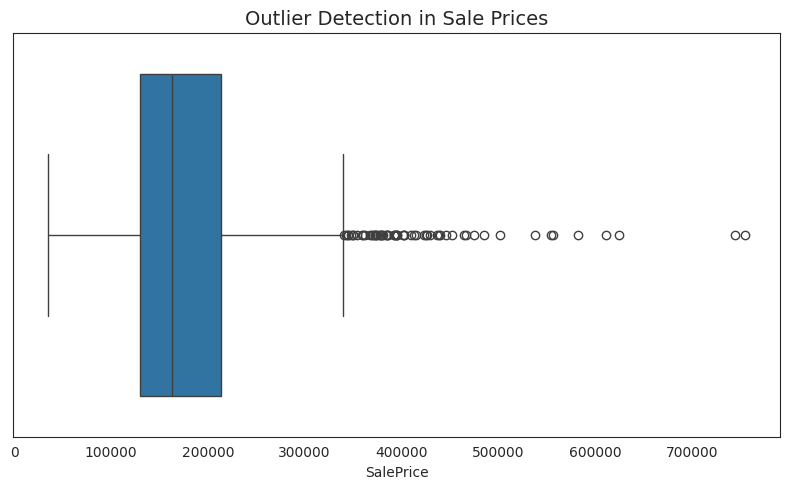

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['SalePrice'])
plt.title("Outlier Detection in Sale Prices", fontsize=14)
plt.tight_layout()
plt.show()


## **Removing Outliers**

In [49]:
df = df[df['SalePrice'] < 500000]

## **Feature Selection**

In [51]:
features = [
    'GrLivArea',
    'BedroomAbvGr',
    'FullBath',
    'GarageCars',
    'GarageArea',
    'OverallQual',
    'YearBuilt',
    'TotRmsAbvGrd'
]

X = df[features]
y = df['SalePrice']

## **Handling Missing Values**

In [52]:
X = X.fillna(X.mean())

## **Train-Test Split and Model Training**

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## **Model Evaluation**

In [54]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 1032518858.0466399
R2 Score: 0.78733682981953


## **Observation**

The Linear Regression model achieved an R² Score of approximately 0.78, indicating good predictive performance on the housing dataset.

## **Actual vs Predicted House Prices**

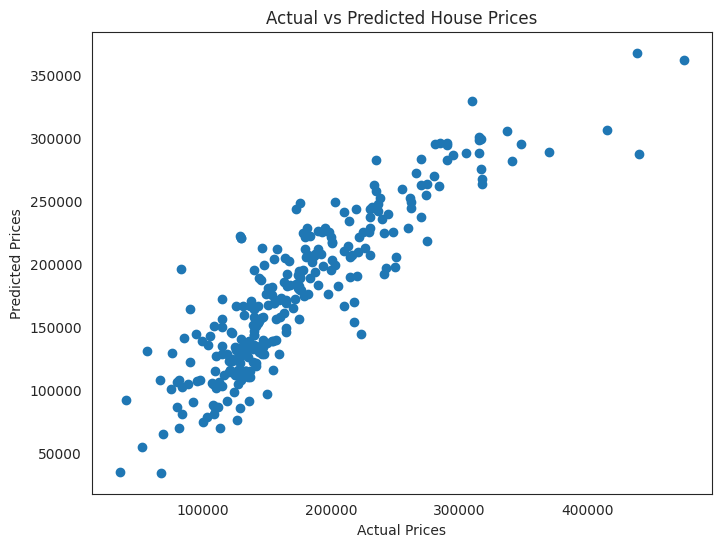

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()